20:12:24 - cmdstanpy - INFO - Chain [1] start processing
20:12:24 - cmdstanpy - INFO - Chain [1] done processing


Prepared data: 731 rows  — from 2023-01-01 to 2024-12-31
Train rows: 622, Test rows: 109
Saved forecast CSV -> forecast_for_tableau.csv
Evaluation on holdout: MAE = 2.2541, RMSE = 2.7811
Saved plot -> forecast_plot.png
Saved components -> components_plot.png
Preview (last 8 rows):
        ds     yhat  yhat_lower  yhat_upper    y  historic
2024-12-24 6.613796    3.638536   10.297070  9.0      True
2024-12-25 7.224431    3.876808   10.525585  8.0      True
2024-12-26 6.842657    3.511505   10.004202 10.0      True
2024-12-27 7.008102    3.744965   10.291681  7.0      True
2024-12-28 7.223684    3.857687   10.597833 11.0      True
2024-12-29 6.771208    3.480125    9.978855 10.0      True
2024-12-30 6.995697    3.579026   10.361179 11.0      True
2024-12-31 6.409509    3.123371    9.811042  5.0      True


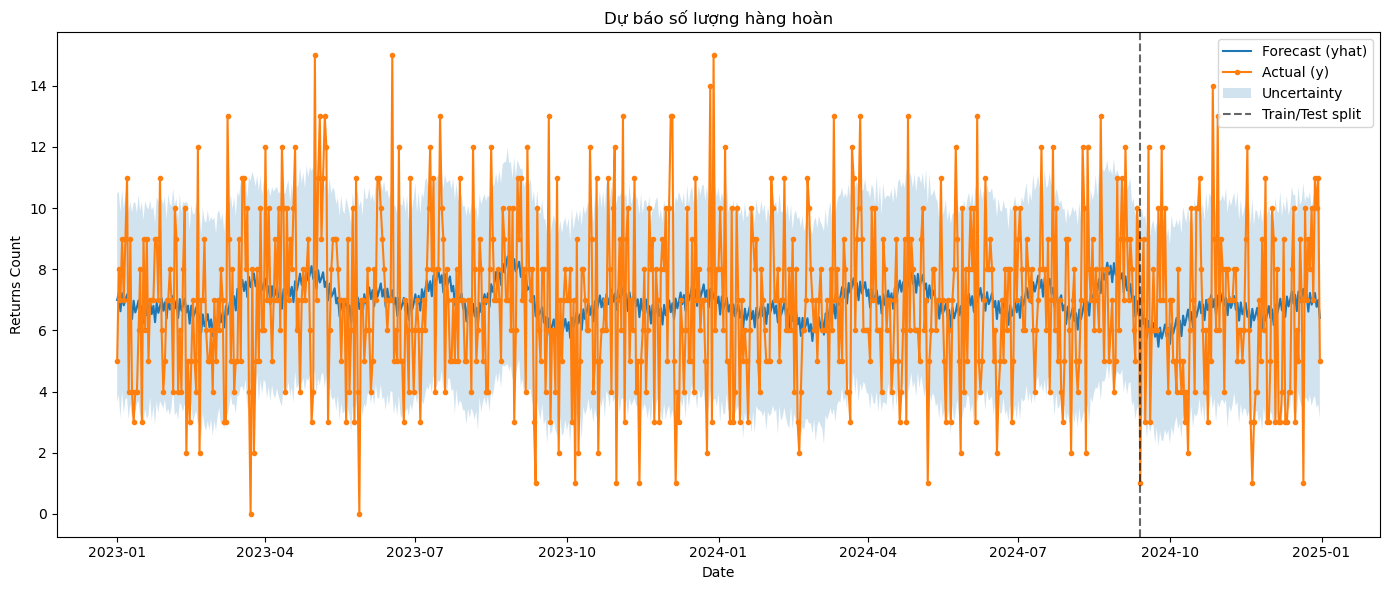

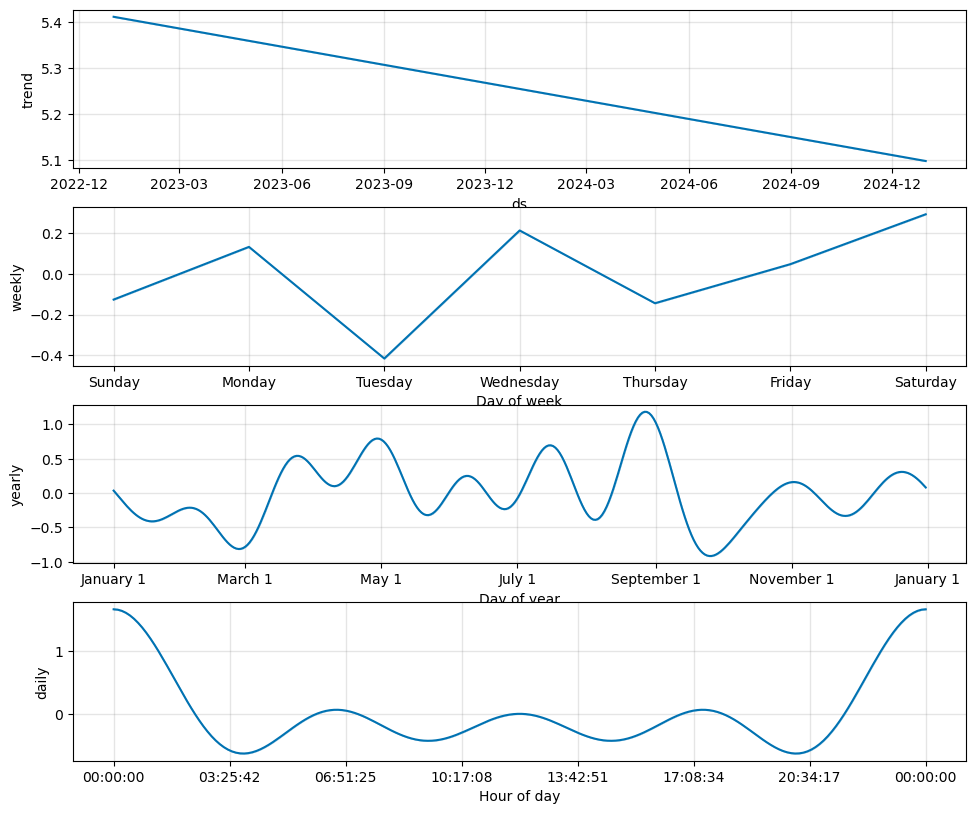

In [3]:
"""
forecast_returns_fixed.py
Phiên bản vá: tương thích với mọi scikit-learn (fallback nếu 'squared' không được hỗ trợ)
Dự báo số lượng hàng hoàn theo Return_Date
"""

import os
import pandas as pd
import numpy as np
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import math

# --- Cấu hình ---
INPUT_FILE = "ecommerce_returns_synthetic_data.csv"   # đổi theo file bạn có
OUTPUT_FORECAST_CSV = "forecast_for_tableau.csv"
FIG_FORECAST = "forecast_plot.png"
FIG_COMPONENTS = "components_plot.png"
FREQ = "D"  # 'D' ngày, 'W' tuần, 'M' tháng
DEBUG_ENV = False  # bật True nếu muốn in phiên bản sklearn / chữ ký hàm

# --- Hàm load & chuẩn hóa ---
def load_and_prepare(path=INPUT_FILE):
    df = pd.read_csv(path)
    # đảm bảo có cột Return_Date và Return_Status
    if "Return_Date" not in df.columns or "Return_Status" not in df.columns:
        raise ValueError("CSV phải có cột 'Return_Date' và 'Return_Status'.")
    df["Return_Date"] = pd.to_datetime(df["Return_Date"], errors="coerce")
    # chỉ chọn những record thực sự returned
    # chấp nhận nhiều cách viết: "returned", "Returned", "RETURNED"
    returns = df[df["Return_Status"].astype(str).str.lower() == "returned"].copy()
    if returns.empty:
        print("CẢNH BÁO: Không tìm thấy record có Return_Status == 'Returned'. Kết quả sẽ toàn 0.")
    # group theo ngày
    daily_returns = (
        returns.groupby("Return_Date")["Order_ID"]
        .count()
        .reset_index()
        .rename(columns={"Return_Date": "ds", "Order_ID": "y"})
    )
    if daily_returns.empty:
        # nếu rỗng, tạo khung ngày rỗng dựa trên ngày đặt hàng (để không crash)
        if "Order_Date" in df.columns:
            min_d = pd.to_datetime(df["Order_Date"], errors="coerce").min()
            max_d = pd.to_datetime(df["Order_Date"], errors="coerce").max()
        else:
            min_d = pd.Timestamp.today() - pd.Timedelta(days=365)
            max_d = pd.Timestamp.today()
        full = pd.DataFrame({"ds": pd.date_range(min_d, max_d, freq=FREQ)})
        full["y"] = 0
        return full
    # reindex full date range
    full = pd.DataFrame({"ds": pd.date_range(daily_returns["ds"].min(), daily_returns["ds"].max(), freq=FREQ)})
    daily_returns = full.merge(daily_returns, on="ds", how="left")
    daily_returns["y"] = daily_returns["y"].fillna(0)
    return daily_returns

# --- Main pipeline ---
def main():
    if DEBUG_ENV:
        import sklearn, inspect
        print("sklearn version:", sklearn.__version__)
        print("mean_squared_error signature:", inspect.signature(mean_squared_error))

    df = load_and_prepare(INPUT_FILE)
    print(f"Prepared data: {len(df)} rows  — from {df['ds'].min().date()} to {df['ds'].max().date()}")

    # train/test split
    test_days = int(max(7, 0.15 * len(df)))
    train_df = df.iloc[:-test_days].copy()
    test_df = df.iloc[-test_days:].copy()
    print(f"Train rows: {len(train_df)}, Test rows: {len(test_df)}")

    # fit Prophet
    m = Prophet(daily_seasonality=True, weekly_seasonality=True, yearly_seasonality=True)
    m.fit(train_df)

    # forecast
    future_periods = max(30, test_days)
    future = m.make_future_dataframe(periods=future_periods, freq=FREQ)
    forecast = m.predict(future)

    # merge history into forecast for saving/plotting
    save_df = forecast[["ds","yhat","yhat_lower","yhat_upper"]].merge(df, on="ds", how="left")
    save_df = save_df.sort_values("ds").reset_index(drop=True)
    save_df["historic"] = save_df["y"].notna()
    save_df.to_csv(OUTPUT_FORECAST_CSV, index=False)
    print("Saved forecast CSV ->", OUTPUT_FORECAST_CSV)

    # Evaluate on test set: join forecast and true y
    eval_df = save_df.copy()
    # pick rows in the original test_ds range
    eval_test = eval_df[eval_df["ds"].isin(test_df["ds"])].copy()
    # drop rows missing y or yhat
    eval_test = eval_test.dropna(subset=["y","yhat"])
    if eval_test.empty:
        print("CẢNH BÁO: Không có điểm để đánh giá (eval_test rỗng sau dropna). Bỏ qua đánh giá.")
        mae = rmse = float("nan")
    else:
        # MAE
        mae = mean_absolute_error(eval_test["y"], eval_test["yhat"])
        # RMSE: thử gọi với squared=False, nếu không được thì fallback
        try:
            # một số môi trường không chấp nhận tham số squared
            rmse = mean_squared_error(eval_test["y"], eval_test["yhat"], squared=False)
        except TypeError:
            mse = mean_squared_error(eval_test["y"], eval_test["yhat"])
            rmse = math.sqrt(mse)
    print(f"Evaluation on holdout: MAE = {mae:.4f}, RMSE = {rmse:.4f}")

    # Plot forecast + actuals
    plt.figure(figsize=(14,6))
    plt.plot(save_df["ds"], save_df["yhat"], label="Forecast (yhat)")
    if save_df["y"].notna().any():
        plt.plot(save_df["ds"], save_df["y"], label="Actual (y)", linestyle='-', marker='o', markersize=3)
    plt.fill_between(save_df["ds"], save_df["yhat_lower"], save_df["yhat_upper"], alpha=0.2, label="Uncertainty")
    plt.axvline(x=train_df["ds"].max(), color="k", linestyle="--", alpha=0.6, label="Train/Test split")
    plt.xlabel("Date")
    plt.ylabel("Returns Count")
    plt.title("Dự báo số lượng hàng hoàn")
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIG_FORECAST, dpi=150)
    print("Saved plot ->", FIG_FORECAST)

    # components
    fig2 = m.plot_components(forecast)
    fig2.set_size_inches(10,8)
    fig2.savefig(FIG_COMPONENTS, dpi=150)
    print("Saved components ->", FIG_COMPONENTS)

    # preview
    print("Preview (last 8 rows):")
    print(save_df.tail(8).to_string(index=False))
    
# === Thêm vào cuối file forecast_returns_fixed.py ===
def forecast_returns(input_file=INPUT_FILE, freq="D", periods=30):
    """
    Hàm dự báo số lượng hàng hoàn, trả về (dataframe, model)
    Dùng cho UI hoặc các script khác.
    """
    df = load_and_prepare(input_file)
    m = Prophet(daily_seasonality=True, weekly_seasonality=True, yearly_seasonality=True)
    m.fit(df)
    future = m.make_future_dataframe(periods=periods, freq=freq)
    forecast = m.predict(future)
    result = forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].merge(df, on="ds", how="left")
    result["historic"] = result["y"].notna()
    return result, m

if __name__ == "__main__":
    main()


In [4]:
import sklearn, inspect
from sklearn.metrics import mean_squared_error
print(sklearn.__version__)
import inspect
print(inspect.signature(mean_squared_error))

1.7.2
(y_true, y_pred, *, sample_weight=None, multioutput='uniform_average')


In [4]:
import ipywidgets as widgets
from IPython.display import display, clear_output, HTML
import matplotlib.pyplot as plt
from forecast_returns_fixed import forecast_returns

# --- Tiêu đề cho app ---
display(HTML("<h2 style='text-align:center; color:#2E86C1;'>📦 Dự báo số lượng hàng hoàn</h2>"))

# === Các widget điều khiển ===
file_input = widgets.Text(
    value="ecommerce_returns_synthetic_data.csv",
    description="Tên file CSV:",
    style={'description_width': 'initial'},
    layout=widgets.Layout(width="450px")
)
freq_dropdown = widgets.Dropdown(
    options=[("Ngày", "D"), ("Tuần", "W"), ("Tháng", "M")],
    value="D",
    description="Tần suất:",
    style={'description_width': 'initial'},
    layout=widgets.Layout(width="300px")
)
period_slider = widgets.IntSlider(
    value=30, min=7, max=180, step=1,
    description="Dự báo (ngày):",
    style={'description_width': 'initial'},
    continuous_update=False,
    layout=widgets.Layout(width="450px")
)
run_button = widgets.Button(
    description="🚀 Chạy dự báo",
    button_style="success",
    layout=widgets.Layout(width="200px", align_self="center")
)

output_area = widgets.Output()

# === Hàm chạy khi bấm nút ===
def on_run_clicked(b):
    with output_area:
        clear_output()
        print("🔄 Đang chạy dự báo...")
        try:
            forecast_df, model = forecast_returns(
                input_file=file_input.value,
                freq=freq_dropdown.value,
                periods=period_slider.value
            )

            plt.figure(figsize=(12,5))
            plt.plot(forecast_df["ds"], forecast_df["yhat"], label="Dự báo (yhat)")
            plt.fill_between(forecast_df["ds"], forecast_df["yhat_lower"], forecast_df["yhat_upper"], alpha=0.2, label="Khoảng tin cậy")
            if forecast_df["y"].notna().any():
                plt.plot(forecast_df["ds"], forecast_df["y"], label="Thực tế (y)", marker="o", markersize=3)
            plt.xlabel("Ngày")
            plt.ylabel("Số lượng hàng hoàn")
            plt.title("Biểu đồ dự báo")
            plt.legend()
            plt.tight_layout()
            plt.show()

            display(forecast_df.tail(10))  # hiển thị 10 dòng cuối
        except Exception as e:
            print("❌ Lỗi khi dự báo:", e)

# Gán sự kiện
run_button.on_click(on_run_clicked)

# === Hiển thị giao diện ===
controls = widgets.VBox([file_input, freq_dropdown, period_slider, run_button])
ui = widgets.VBox([controls, output_area], layout=widgets.Layout(align_items='center'))
display(ui)
